# LLM Debate Reproduction (OpenRouter Version)
This notebook follows the **original paper logic exactly** while adapting execution to OpenRouter.

Key points:
- Same model for all agents
- Debate vs single-agent comparison
- Original evaluation loop (no optimization)
- Results stored in JSON files

## Setup

In [ ]:

import json
import random
import time
import numpy as np
from tqdm import tqdm
from openai import OpenAI


import requests
import numpy as np
import time

from dotenv import load_dotenv
import os

load_dotenv("../.env")

## LLMs API

In [ ]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

# MODEL = "mistralai/mixtral-8x7b-instruct"
MODEL = "gpt-5.4-mini"

client = OpenAI(
    api_key=OPENAI_API_KEY,
)

print("Client initialized successfully")
print("Models:", MODEL)

Client initialized successfully
Models: gpt-5.4-mini


In [3]:
def call_model(messages):
    completion = client.chat.completions.create(
        model=MODEL,
        messages=messages,
    )

    return completion

## Utility Functions

In [4]:
def parse_bullets(sentence):
    bullets_preprocess = sentence.split("\n")
    bullets = []

    for bullet in bullets_preprocess:
        try:
            idx = bullet.find(next(filter(str.isalpha, bullet)))
        except:
            continue

        bullet = bullet[idx:]

        if len(bullet) != 0:
            bullets.append(bullet)

    return bullets


def filter_people(person):
    people = person.split("(")[0]
    return people


def construct_message(agents, idx, person, final=False):
    prefix_string = "Here are some bullet point biographies of {} given by other agents: ".format(person)

    if len(agents) == 0:
        return {"role": "user", "content": "Closely examine your biography and provide an updated bullet point biography."}

    for i, agent in enumerate(agents):
        agent_response = agent[idx]["content"]
        response = "\n\n Agent response: ```{}```".format(agent_response)
        prefix_string = prefix_string + response

    if final:
        prefix_string = prefix_string + "\n\n Closely examine your biography and the biography of other agents and provide an updated bullet point biography."
    else:
        prefix_string = prefix_string + "\n\n Using these other biographies of {} as additional advice, what is your updated bullet point biography of the computer scientist {}?".format(person, person)

    return {"role": "user", "content": prefix_string}


def construct_assistant_message(completion):
    content = completion.choices[0].message.content
    return {"role": "assistant", "content": content}


def extract_final_answer(agent_contexts, agent_idx=0):
    return agent_contexts[agent_idx][-1]["content"]


# Load Biography Dataset

Load the original biography dataset from `article.json`.

Dataset format:
```json
{
    "Alan Turing": "...",
    "Ada Lovelace": "..."
}
```


In [5]:
DATASET_SIZE = 100

# Output file
OUTPUT_FILE = "biography_debate_results_e3.json"

In [6]:

with open("articles.json", "r") as f:
    data = json.load(f)

print("Dataset loaded successfully")
print(f"Total records: {len(data)}")


next(iter(data.values()), "No value found")

Dataset loaded successfully
Total records: 524


"- Aaron Sloman is a philosopher and researcher on artificial intelligence and cognitive science\n- He held the Chair in Artificial Intelligence and Cognitive Science at the School of Computer Science at the University of Birmingham and previously at the University of Sussex\n- Sloman has published widely on philosophy of mathematics, epistemology, cognitive science, and artificial intelligence and collaborated with biologist Jackie Chappell on the evolution of intelligence\n- He was born in Southern Rhodesia (now Zimbabwe) to Lithuanian Jewish parents, and went to school in Cape Town before earning a degree in Mathematics and Physics at the University of Cape Town and a DPhil in philosophy at the University of Oxford\n- Sloman's philosophical ideas were influenced by Immanuel Kant, Gottlob Frege, Karl Popper and others, and his work in AI by Marvin Minsky and John McCarthy\n- He is a Fellow of several AI and philosophy associations and received the K. Jon Barwise Prize for contributio

In [7]:
# Extract people names
people = sorted(data.keys())

print("Old Data")
print(people[:5])

# Clean names
people = [filter_people(person) for person in people]

# Shuffle for reproducibility
random.seed(0)
random.shuffle(people)

print("\nClean Data:")
print(people[:5])

Old Data
['Aaron Sloman', 'Abhay Bhushan', 'Adam Dunkels', 'Adele Goldberg (computer scientist)', 'Adi Shamir']

Clean Data:
['Shakuntala Atre', 'Butler Lampson', 'Luca Cardelli', 'Philip Don Estridge', 'Gillian Lovegrove']


## Generation (Single vs Debate)

Pipeline:
1. Each agent generates a biography
2. Agents review other responses
3. Debate rounds refine biographies
4. Final responses are stored

Intermediate outputs are printed to understand the full debate process.

In [8]:
def generate_single(person):
    messages = [{
        "role": "user",
        "content": "Give a bullet point biography of {} highlighting their contributions and achievements as a computer scientist, with each fact separated with a new line character. ".format(person)
    }]
    completion = call_model(messages)
    return completion.choices[0].message.content


def generate_debate(person, agents=3, rounds=2):
    agent_contexts = [[{"role": "user", "content": "Give a bullet point biography of {} highlighting their contributions and achievements as a computer scientist, with each fact separated with a new line character. ".format(person)}] for _ in range(agents)]

    for round in range(rounds):
        for i, agent_context in enumerate(agent_contexts):

            if round != 0:
                agent_contexts_other = agent_contexts[:i] + agent_contexts[i+1:]

                if round == (rounds - 1):
                    message = construct_message(agent_contexts_other, 2*round - 1, person=person, final=True)
                else:
                    message = construct_message(agent_contexts_other, 2*round - 1, person=person, final=False)

                agent_context.append(message)

            completion = call_model(agent_context)
            assistant_message = construct_assistant_message(completion)
            agent_context.append(assistant_message)

            bullets = parse_bullets(assistant_message["content"])

            if len(bullets) == 1:
                break

    return agent_contexts

In [9]:
generated_description = {}

start_time = time.time()
for person in tqdm(people[:DATASET_SIZE]):

    # --- Single ---
    single_output = generate_single(person)

    # --- Debate (unchanged function) ---
    debate_contexts = generate_debate(person, agents=3, rounds=2)

    # --- Extract final answer ---
    debate_output = extract_final_answer(debate_contexts, agent_idx=0)

    # --- Store clean ---
    generated_description[person] = {
        "single": single_output,
        "debate": debate_output
    }

    # save progressively
    with open(OUTPUT_FILE, "w") as f:
        json.dump(generated_description, f, indent=2)

end_time = time.time()
print(f"\nTotal Time: {(end_time - start_time) / 60:.2f} mins")

100%|███████████████████████████████████████████████████████| 100/100 [30:45<00:00, 18.45s/it]


Total Time: 30.76 mins


## Evaluation

In [11]:
def parse_yes_no(string):
    if "uncertain" in string.lower():
        return None
    elif "yes" in string.lower():
        return True
    elif "no" in string.lower():
        return False
    else:
        return None

def evaluate(results_file, article_file, output_file="evaluation.json"):
    response = json.load(open(results_file, "r"))

    with open(article_file, "r") as f:
        gt_data = json.load(f)

    # normalize names
    gt_data_filter = {}
    for k, v in gt_data.items():
        k = filter_people(k)
        gt_data_filter[k] = v

    gt_data = gt_data_filter
    people = list(response.keys())

    accuracies = []
    eval_log = []

    for person in people[:51]:

        if person not in gt_data:
            continue

        gt_description = gt_data[person]
        gt_bullets = parse_bullets(gt_description)

        # 👇 FIX: handle single + debate explicitly
        for mode in ["single", "debate"]:

            bio_description = response[person][mode]
            bio_bullets = parse_bullets(bio_description)

            if len(bio_bullets) == 1:
                if len(bio_bullets[0]) < 400:
                    continue

            bio_bullets_joined = " ".join(bio_bullets)

            for bullet in gt_bullets:

                message = [{
                    "role": "user",
                    "content": f"""Consider the following biography of {person}:
{bio_bullets_joined}

Is the above biography consistent with the fact below?

{bullet}

Give a single word answer: yes, no, or uncertain.
Carefully check precise dates and locations."""
                }]

                try:
                    completion = call_model(message)
                    content = completion.choices[0].message.content
                except Exception as e:
                    print("Retrying...", e)
                    time.sleep(5)
                    continue

                accurate = parse_yes_no(content)

                eval_log.append({
                    "person": person,
                    "mode": mode,
                    "fact": bullet,
                    "response": content,
                    "parsed": accurate
                })

                if accurate is not None:
                    accuracies.append(float(accurate))

        # live progress
        print(
            "accuracy:",
            np.mean(accuracies),
            "stderr:",
            np.std(accuracies) / (len(accuracies) ** 0.5)
        )

        # SAVE AFTER EACH PERSON
        with open(output_file, "w") as f:
            json.dump({
                "mean_accuracy": float(np.mean(accuracies)),
                "stderr": float(np.std(accuracies) / (len(accuracies) ** 0.5)),
                "raw": eval_log
            }, f, indent=2)

    print(f"Saved to {output_file}")

In [16]:
def evaluate(results_file, article_file, output_file="evaluation.json"):
    response = json.load(open(results_file, "r"))

    with open(article_file, "r") as f:
        gt_data = json.load(f)

    # normalize names
    gt_data_filter = {}
    for k, v in gt_data.items():
        k = filter_people(k)
        gt_data_filter[k] = v

    gt_data = gt_data_filter
    people = list(response.keys())

    # 🔥 separate tracking
    accuracies = {
        "single": [],
        "debate": []
    }

    eval_log = []

    for person in people:

        if person not in gt_data:
            continue

        gt_description = gt_data[person]
        gt_bullets = parse_bullets(gt_description)
        print(f"""------{person}""")

        for mode in ["single", "debate"]:

            bio_description = response[person][mode]
            bio_bullets = parse_bullets(bio_description)

            if len(bio_bullets) == 1:
                if len(bio_bullets[0]) < 400:
                    continue

            bio_bullets_joined = " ".join(bio_bullets)

            for bullet in gt_bullets:

                message = [{
                    "role": "user",
                    "content": f"""Consider the following biography of {person}:
{bio_bullets_joined}

Is the above biography consistent with the fact below?

{bullet}

Give a single word answer: yes, no, or uncertain.
Carefully check precise dates and locations."""
                }]

                try:
                    completion = call_model(message)
                    content = completion.choices[0].message.content
                except Exception as e:
                    print("Retrying...", e)
                    time.sleep(5)
                    continue

                accurate = parse_yes_no(content)

                eval_log.append({
                    "person": person,
                    "mode": mode,
                    "fact": bullet,
                    "response": content,
                    "parsed": accurate
                })

                if accurate is not None:
                    accuracies[mode].append(float(accurate))

        # 📊 live stats
        def stats(arr):
            if len(arr) == 0:
                return 0, 0
            return np.mean(arr), np.std(arr) / (len(arr) ** 0.5)

        single_mean, single_err = stats(accuracies["single"])
        debate_mean, debate_err = stats(accuracies["debate"])

        print(f"""Single  → mean: {single_mean:.4f}, stderr: {single_err:.4f} \nDebate  → mean: {debate_mean:.4f}, stderr: {debate_err:.4f}""")

        # 🔥 save progressively
        with open(output_file, "w") as f:
            json.dump({
                "single": {
                    "mean_accuracy": float(single_mean),
                    "stderr": float(single_err),
                    "count": len(accuracies["single"])
                },
                "debate": {
                    "mean_accuracy": float(debate_mean),
                    "stderr": float(debate_err),
                    "count": len(accuracies["debate"])
                },
                "raw": eval_log
            }, f, indent=2)

    print(f"Saved to {output_file}")

In [17]:
evaluate(OUTPUT_FILE, "articles.json")

Single  → mean: 0.5714, stderr: 0.1870 
Debate  → mean: 0.5000, stderr: 0.2041
Single  → mean: 0.7333, stderr: 0.1142 
Debate  → mean: 0.7143, stderr: 0.1207
Single  → mean: 0.7826, stderr: 0.0860 
Debate  → mean: 0.6667, stderr: 0.1029
Single  → mean: 0.8485, stderr: 0.0624 
Debate  → mean: 0.7333, stderr: 0.0807
Single  → mean: 0.7179, stderr: 0.0721 
Debate  → mean: 0.8000, stderr: 0.0632
Single  → mean: 0.7083, stderr: 0.0656 
Debate  → mean: 0.7917, stderr: 0.0586
Single  → mean: 0.7500, stderr: 0.0579 
Debate  → mean: 0.8214, stderr: 0.0512
Single  → mean: 0.7812, stderr: 0.0517 
Debate  → mean: 0.8281, stderr: 0.0472
Single  → mean: 0.7639, stderr: 0.0501 
Debate  → mean: 0.8286, stderr: 0.0450
Single  → mean: 0.7927, stderr: 0.0448 
Debate  → mean: 0.8354, stderr: 0.0417
Single  → mean: 0.8090, stderr: 0.0417 
Debate  → mean: 0.8506, stderr: 0.0382
Single  → mean: 0.8283, stderr: 0.0379 
Debate  → mean: 0.8557, stderr: 0.0357
Single  → mean: 0.8455, stderr: 0.0345 
Debate  → me

# Display Results

In [19]:
summary = {}
for stage, values in accuracies.items():
    summary[stage] = {
        "count": len(values),
        "mean_accuracy": float(np.mean(values)) if values else None,
        "standard_error": float(np.std(values) / (len(values) ** 0.5)) if len(values) > 0 else None,
    }

if any(summary[s]["count"] > 0 for s in summary):
    print("================================================")
    print("FINAL EVALUATION")
    for stage, stats in summary.items():
        print(f"{stage.title()} Mean Accuracy: {stats['mean_accuracy']}")
        print(f"{stage.title()} Standard Error: {stats['standard_error']}")
else:
    print("No valid evaluation results")

NameError: name 'accuracies' is not defined

In [25]:
import json
import numpy as np

def summarize_from_file(file_path):
    data = json.load(open(file_path))

    raw = data["raw"]

    # rebuild accuracies dict from file
    accuracies = {
        "single": [],
        "debate": []
    }

    for entry in raw:
        mode = entry["mode"]
        parsed = entry["parsed"]

        if parsed is not None:
            accuracies[mode].append(float(parsed))

    # compute summary
    summary = {}
    for stage, values in accuracies.items():
        summary[stage] = {
            "count": len(values),
            "mean_accuracy": float(np.mean(values)) if values else None,
            "standard_error": float(np.std(values) / (len(values) ** 0.5)) if len(values) > 0 else None,
        }

    # print results
    if any(summary[s]["count"] > 0 for s in summary):
        print("================================================")
        print("FINAL EVALUATION")
        for stage, stats in summary.items():
            print(f"{stage.title()} Mean Accuracy: {stats['mean_accuracy']}")
            print(f"{stage.title()} Standard Error: {stats['standard_error']}")
    else:
        print("No valid evaluation results")

    return summary


summary = summarize_from_file("evaluation.json")

FINAL EVALUATION
Single Mean Accuracy: 0.8942786069651741
Single Standard Error: 0.010844008140408964
Debate Mean Accuracy: 0.8902291917973462
Debate Standard Error: 0.010857181080941528


User Single Accuracy: 0.894
User Debate Accuracy: 0.890
Paper Single Accuracy: 0.660
Paper Debate Accuracy: 0.740


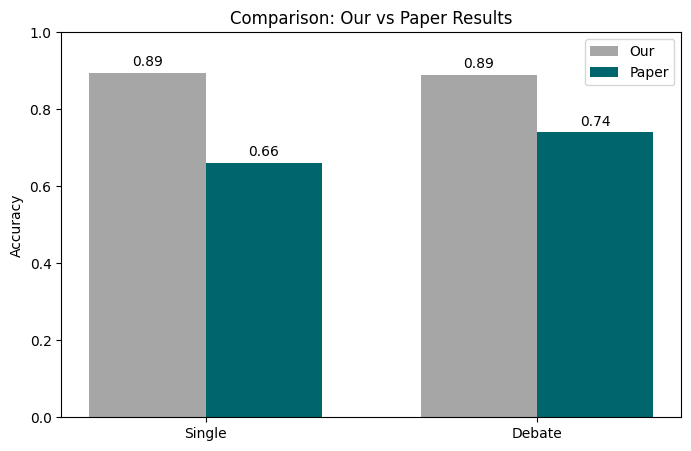

In [36]:
# Comparison with Paper Results

import matplotlib.pyplot as plt

# User's results (assuming summary is available from previous cell)
user_single = summary.get("single", {}).get("mean_accuracy", 0)
user_debate = summary.get("debate", {}).get("mean_accuracy", 0)

# Paper's results
paper_single = 0.66
paper_debate = 0.74

print(f"User Single Accuracy: {user_single:.3f}")
print(f"User Debate Accuracy: {user_debate:.3f}")
print(f"Paper Single Accuracy: {paper_single:.3f}")
print(f"Paper Debate Accuracy: {paper_debate:.3f}")

# Plot comparison
stages = ["Single", "Debate"]
user_means = [user_single, user_debate]
paper_means = [paper_single, paper_debate]

x = range(len(stages))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([i - width/2 for i in x], user_means, width, label='Our', color='#a6a6a6')
ax.bar([i + width/2 for i in x], paper_means, width, label='Paper', color='#01656d')

ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_ylabel('Accuracy')
ax.set_title('Comparison: Our vs Paper Results')
ax.legend()

# Add value labels
for i, (user_val, paper_val) in enumerate(zip(user_means, paper_means)):
    ax.text(i - width/2, user_val + 0.01, f'{user_val:.2f}', ha='center', va='bottom')
    ax.text(i + width/2, paper_val + 0.01, f'{paper_val:.2f}', ha='center', va='bottom')

plt.ylim(0, 1)
plt.show()